# 03. Gom nhóm người dùng bằng K-Means Clustering

**Project:** `social-anomaly-clustering`  
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong phát hiện hành vi bất thường của người dùng mạng xã hội  
**Dataset:** Twitter Bot Detection Dataset  
**Notebook:** `03_kmeans_clustering.ipynb`

Notebook này thực hiện bước **gom nhóm người dùng bằng thuật toán K-Means** dựa trên tập đặc trưng đã được tiền xử lý và chuẩn hóa ở notebook trước.

## Mục tiêu

1. Đọc dữ liệu đặc trưng đã chuẩn hóa.
2. Tìm số cụm phù hợp bằng **Elbow Method**.
3. Đánh giá số cụm bằng **Silhouette Score**.
4. Chạy K-Means Clustering.
5. Gán nhãn cụm cho từng người dùng.
6. Tính `anomaly_score` dựa trên khoảng cách đến tâm cụm gần nhất.
7. Xác định nhóm người dùng bất thường theo top 5% `anomaly_score`.
8. Phân tích tỷ lệ bot theo từng cụm và theo nhóm bất thường.
9. Trực quan hóa kết quả bằng PCA.
10. Lưu mô hình, bảng kết quả và biểu đồ.

In [1]:
pip install pandas numpy seaborn matplotlib pyyaml scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import thư viện và thiết lập đường dẫn

Notebook này sử dụng file đầu vào đã được tạo từ bước 02:

```text
datasets/processed/user_features_scaled.csv
datasets/processed/user_features_with_label.csv
```

Trong đó:

- `user_features_scaled.csv`: dữ liệu số đã chuẩn hóa, dùng làm đầu vào cho K-Means.
- `user_features_with_label.csv`: dữ liệu có `user_id` và `bot_label`, dùng để ghép kết quả và đánh giá sau cùng.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

SCALED_FEATURES_PATH = Path("../datasets/processed/user_features_scaled.csv")
FEATURES_WITH_LABEL_PATH = Path("../datasets/processed/user_features_with_label.csv")

RESULT_CSV_DIR = Path("../results/csv")
FIGURE_DIR = Path("../results/figures")
MODEL_DIR = Path("../results/models")

RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df_scaled = pd.read_csv(SCALED_FEATURES_PATH)
df_with_label = pd.read_csv(FEATURES_WITH_LABEL_PATH)

print("Scaled features shape:", df_scaled.shape)
print("Features with label shape:", df_with_label.shape)

Scaled features shape: (50000, 9)
Features with label shape: (50000, 11)


,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days
0,1.199224,-0.885993,-0.915548,-1.00016,1.236852,-1.640290,-1.462696,-2.234834,1.359161
1,0.171153,1.455179,1.607800,0.99984,0.872584,1.432833,-0.292661,0.447460,-1.212668
2,-1.508029,-0.300700,-0.217320,0.99984,-0.098798,0.067001,-0.292661,0.447460,-0.907817
3,0.136884,1.455179,-0.954107,0.99984,-0.827335,-1.298831,0.877374,0.447460,0.084332
4,-0.822649,0.284593,1.198243,-1.00016,-2.041562,-1.298831,-0.292661,0.447460,1.436760


## 2. Đọc dữ liệu đầu vào

Đọc dữ liệu đã chuẩn hóa và dữ liệu có nhãn dùng để đánh giá.

In [10]:
df_scaled.head()

,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days
0,1.199224,-0.885993,-0.915548,-1.00016,1.236852,-1.640290,-1.462696,-2.234834,1.359161
1,0.171153,1.455179,1.607800,0.99984,0.872584,1.432833,-0.292661,0.447460,-1.212668
2,-1.508029,-0.300700,-0.217320,0.99984,-0.098798,0.067001,-0.292661,0.447460,-0.907817
3,0.136884,1.455179,-0.954107,0.99984,-0.827335,-1.298831,0.877374,0.447460,0.084332
4,-0.822649,0.284593,1.198243,-1.00016,-2.041562,-1.298831,-0.292661,0.447460,1.436760


In [9]:
df_with_label.head()

,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label
0,132131,85,1,2353,0,83,5,0,0,1114,1
1,289683,55,5,9617,1,77,14,2,1,186,0
2,779715,6,2,4363,1,61,10,2,1,296,0
3,696168,54,5,2242,1,49,6,4,1,654,1
4,704441,26,3,8438,0,29,6,2,1,1142,1


**Nhận xét:**

`df_scaled` chỉ chứa các đặc trưng đã chuẩn hóa, dùng trực tiếp cho K-Means.  
`df_with_label` chứa thêm `user_id` và `bot_label` để sau khi gom nhóm có thể phân tích xem cụm nào chứa nhiều bot hơn.

## 3. Kiểm tra dữ liệu trước khi clustering

K-Means yêu cầu dữ liệu đầu vào là dạng số và không có giá trị thiếu.

In [11]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   retweet_count     50000 non-null  float64
 1   mention_count     50000 non-null  float64
 2   follower_count    50000 non-null  float64
 3   verified          50000 non-null  float64
 4   tweet_length      50000 non-null  float64
 5   username_length   50000 non-null  float64
 6   hashtag_count     50000 non-null  float64
 7   has_hashtag       50000 non-null  float64
 8   account_age_days  50000 non-null  float64
dtypes: float64(9)
memory usage: 3.4 MB


In [12]:
missing_scaled = pd.DataFrame({
    "missing_count": df_scaled.isnull().sum(),
    "missing_percent": (df_scaled.isnull().sum() / len(df_scaled) * 100).round(2)
})

missing_scaled

,missing_count,missing_percent
retweet_count,0,0.0
mention_count,0,0.0
follower_count,0,0.0
verified,0,0.0
tweet_length,0,0.0
username_length,0,0.0
hashtag_count,0,0.0
has_hashtag,0,0.0
account_age_days,0,0.0


In [13]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
retweet_count,50000.0,-4.376943e-17,1.00001,-1.713643,-0.856918,-0.000192,0.856534,1.713259
mention_count,50000.0,8.384404e-18,1.00001,-1.471286,-0.885993,0.284593,0.869886,1.455179
follower_count,50000.0,-9.251266e-17,1.00001,-1.732927,-0.868739,0.001007,0.862329,1.740846
verified,50000.0,6.835421e-17,1.00001,-1.000160,-1.000160,0.999840,0.999840,0.999840
tweet_length,50000.0,2.117417e-16,1.00001,-2.405830,-0.827335,-0.038087,0.811873,3.361750
username_length,50000.0,1.022471e-16,1.00001,-2.323206,-0.957373,-0.274457,0.749917,3.823040
hashtag_count,50000.0,1.875833e-17,1.00001,-1.462696,-0.877678,-0.292661,0.877374,1.462392
has_hashtag,50000.0,-9.833911e-17,1.00001,-2.234834,0.447460,0.447460,0.447460,0.447460
account_age_days,50000.0,3.922196e-17,1.00001,-1.728142,-0.863475,-0.007123,0.871401,1.724982


**Nhận xét:**

Dữ liệu đã được chuẩn hóa bằng `StandardScaler`, nên trung bình của các feature thường gần 0 và độ lệch chuẩn gần 1. Điều này phù hợp cho K-Means vì thuật toán sử dụng khoảng cách giữa các điểm dữ liệu để gom nhóm.

## 4. Elbow Method

**Elbow Method** dùng để khảo sát số cụm `k` phù hợp cho K-Means.

Ý tưởng:

- Chạy K-Means với nhiều giá trị `k`.
- Tính `inertia`, tức tổng khoảng cách bình phương từ các điểm đến tâm cụm gần nhất.
- Khi tăng `k`, inertia thường giảm.
- Điểm mà tốc độ giảm bắt đầu chậm lại được xem là “khuỷu tay” và có thể chọn làm số cụm phù hợp.

Trong notebook này, thử `k` từ 2 đến 10.

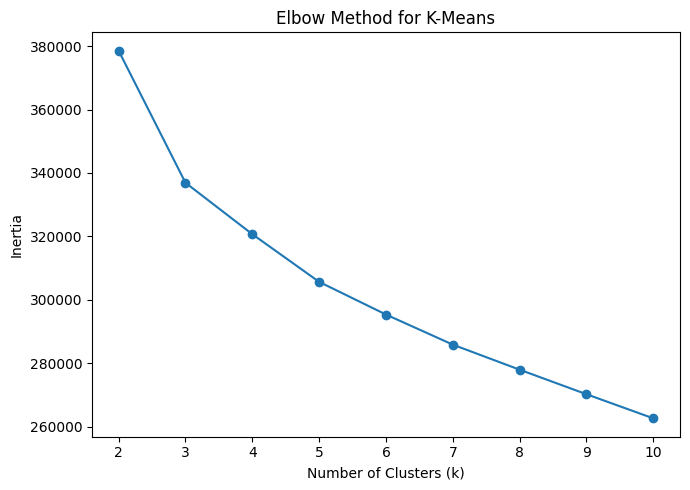

In [3]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "elbow_method.png", dpi=300)
plt.show()

**Nhận xét gợi ý:**

Nếu biểu đồ giảm mạnh từ `k = 2` sang `k = 3`, sau đó giảm chậm hơn, có thể xem `k = 3` là một lựa chọn hợp lý để phục vụ phân tích nhiều nhóm hành vi.

Tuy nhiên, nếu biểu đồ không có đường gấp khúc quá rõ ràng, cần kết hợp thêm chỉ số khác như **Silhouette Score**.

## 5. Silhouette Score

**Silhouette Score** đánh giá mức độ tách biệt giữa các cụm.

Giá trị nằm trong khoảng:

```text
-1 đến 1
```

Ý nghĩa:

- Gần 1: điểm dữ liệu nằm trong cụm phù hợp và xa các cụm khác.
- Gần 0: cụm bị chồng lấn.
- Âm: điểm dữ liệu có thể bị gán sai cụm.

Silhouette Score càng cao thì kết quả gom nhóm càng tốt.

In [4]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.230892
1,3,0.151312
2,4,0.123396
3,5,0.124073
4,6,0.117236
5,7,0.113757
6,8,0.105601
7,9,0.104006
8,10,0.106518


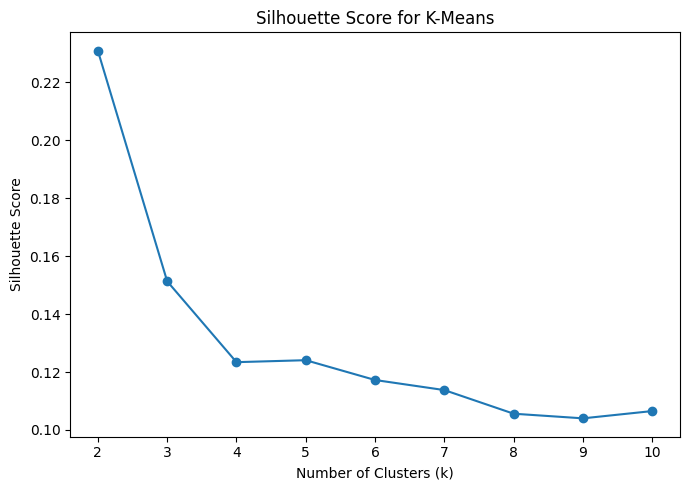

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "silhouette_score.png", dpi=300)
plt.show()

In [14]:
best_k_by_silhouette = silhouette_df.loc[
    silhouette_df["silhouette_score"].idxmax(),
    "k"
]

best_score = silhouette_df["silhouette_score"].max()

print("Best k by Silhouette Score:", best_k_by_silhouette)
print("Best Silhouette Score:", round(best_score, 6))

Best k by Silhouette Score: 2
Best Silhouette Score: 0.230892


**Nhận xét:**

Nếu `k = 2` có Silhouette Score cao nhất, điều đó cho thấy dữ liệu có xu hướng tách tốt nhất thành 2 cụm theo tiêu chí định lượng.

Tuy nhiên, trong đề tài này, có thể chọn `k = 3` nếu muốn phân tích người dùng theo nhiều nhóm hành vi hơn, ví dụ:

```text
Cụm hành vi thấp / bình thường
Cụm hành vi trung bình
Cụm hành vi cao hoặc đáng nghi
```

Khi viết báo cáo, cần nêu rõ lý do chọn `k`.

## 6. Chọn số cụm chính thức cho K-Means

Có hai cách chọn:

1. **Theo metric:** chọn `k` có Silhouette Score cao nhất.
2. **Theo mục tiêu phân tích:** chọn `k = 3` để phân tích nhiều nhóm hành vi hơn.

Trong notebook này, mặc định chọn:

```text
best_k = 3
```

Lý do: đề tài hướng đến phân tích hành vi người dùng theo nhiều nhóm, không chỉ tách thành hai cụm.  
Nếu muốn chọn hoàn toàn theo Silhouette Score, có thể đổi `best_k = int(best_k_by_silhouette)`.

In [ ]:
best_k = 3

print("Selected k for final K-Means:", best_k)

## 7. Huấn luyện K-Means chính thức

Sau khi chọn `k`, tiến hành chạy K-Means trên dữ liệu đã chuẩn hóa.

In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(df_scaled)

df_kmeans_result = df_with_label.copy()
df_kmeans_result["cluster"] = cluster_labels

df_kmeans_result.head()

,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,cluster
0,132131,85,1,2353,0,83,5,0,0,1114,1,1
1,289683,55,5,9617,1,77,14,2,1,186,0,0
2,779715,6,2,4363,1,61,10,2,1,296,0,0
3,696168,54,5,2242,1,49,6,4,1,654,1,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,2


In [15]:
df_kmeans_result["cluster"].value_counts().sort_index()

cluster
0    20845
1     8341
2    20814
Name: count, dtype: int64

**Nhận xét:**

Sau khi chạy K-Means, mỗi người dùng được gán vào một cụm hành vi. Cột `cluster` là nhãn cụm do thuật toán tạo ra, không phải nhãn bot/human.

## 8. Tính Anomaly Score bằng khoảng cách đến tâm cụm

Với K-Means, một cách đơn giản để phát hiện bất thường là tính khoảng cách từ mỗi điểm dữ liệu đến tâm cụm gần nhất.

Ý tưởng:

```text
Người dùng càng xa tâm cụm gần nhất → hành vi càng khác với nhóm chính → anomaly_score càng cao
```

Công thức trực quan:

```text
anomaly_score = distance(user, nearest_cluster_center)
```

In [7]:
distances = kmeans.transform(df_scaled)

nearest_cluster_distance = distances.min(axis=1)

df_kmeans_result["anomaly_score"] = nearest_cluster_distance

df_kmeans_result[["user_id", "cluster", "anomaly_score", "bot_label"]].head()

,user_id,cluster,anomaly_score,bot_label
0,132131,1,3.164121,1
1,289683,0,3.057194,0
2,779715,0,1.897890,0
3,696168,0,2.395977,1
4,704441,2,3.228215,1


In [16]:
df_kmeans_result["anomaly_score"].describe()

count    50000.000000
mean         2.551833
std          0.475855
min          0.596834
25%          2.242604
50%          2.560933
75%          2.869805
max          4.638261
Name: anomaly_score, dtype: float64

## 9. Xác định nhóm bất thường

Trong notebook này, chọn **top 5% người dùng có `anomaly_score` cao nhất** làm nhóm bất thường.

Vì dataset có 50,000 bản ghi nên top 5% tương ứng với khoảng:

```text
50,000 × 5% = 2,500 người dùng
```

Có thể thay đổi ngưỡng này tùy mục tiêu nghiên cứu, ví dụ top 1%, 3%, 5% hoặc 10%.

In [17]:
anomaly_percentile = 0.95

threshold = df_kmeans_result["anomaly_score"].quantile(anomaly_percentile)

df_kmeans_result["is_anomaly"] = (
    df_kmeans_result["anomaly_score"] >= threshold
).astype(int)

print("Anomaly threshold:", threshold)
df_kmeans_result["is_anomaly"].value_counts()

Anomaly threshold: 3.314574966957724


is_anomaly
0    47500
1     2500
Name: count, dtype: int64

**Nhận xét:**

Nếu chọn ngưỡng top 5%, số người dùng được đánh dấu bất thường sẽ chiếm khoảng 5% tổng số bản ghi. Các user này không nhất thiết đều là bot, nhưng là những tài khoản có hành vi lệch xa tâm cụm theo đặc trưng đã chọn.

## 10. Phân tích cụm K-Means

Tạo bảng thống kê theo từng cụm để xem cụm nào có hành vi nổi bật hơn.

Các chỉ số gồm:

- Số lượng user trong cụm.
- Số lượng bot trong cụm.
- Tỷ lệ bot trong cụm.
- Anomaly score trung bình.
- Trung bình các feature hành vi như retweet, mention, follower, hashtag.

In [18]:
cluster_summary = df_kmeans_result.groupby("cluster").agg(
    user_count=("user_id", "count"),
    bot_count=("bot_label", "sum"),
    bot_ratio=("bot_label", "mean"),
    avg_anomaly_score=("anomaly_score", "mean"),
    avg_retweet_count=("retweet_count", "mean"),
    avg_mention_count=("mention_count", "mean"),
    avg_follower_count=("follower_count", "mean"),
    avg_verified=("verified", "mean"),
    avg_tweet_length=("tweet_length", "mean"),
    avg_username_length=("username_length", "mean"),
    avg_hashtag_count=("hashtag_count", "mean"),
    avg_account_age_days=("account_age_days", "mean")
).reset_index()

cluster_summary["bot_ratio"] = (cluster_summary["bot_ratio"] * 100).round(2)
cluster_summary["avg_verified"] = (cluster_summary["avg_verified"] * 100).round(2)

cluster_summary.round(2)

,cluster,user_count,bot_count,bot_ratio,avg_anomaly_score,avg_retweet_count,avg_mention_count,avg_follower_count,avg_verified,avg_tweet_length,avg_username_length,avg_hashtag_count,avg_account_age_days
0,0,20845,10368,49.74,2.54,50.11,2.52,4980.80,100.00,62.55,9.81,3.01,621.95
1,1,8341,4180,50.11,2.60,50.28,2.51,4977.29,49.86,62.85,9.78,0.00,624.94
2,2,20814,10470,50.30,2.54,49.79,2.51,5000.95,0.00,62.62,9.81,2.99,624.65


In [20]:
from pathlib import Path

RESULT_CSV_DIR = Path("../results/csv")
RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_SUMMARY_PATH = RESULT_CSV_DIR / "cluster_summary.csv"

In [21]:
cluster_summary.to_csv(CLUSTER_SUMMARY_PATH, index=False)
print("Saved cluster summary to:", CLUSTER_SUMMARY_PATH)

Saved cluster summary to: ../results/csv/cluster_summary.csv


**Diễn giải `cluster_summary`:**

- Cụm có `bot_ratio` cao hơn có thể chứa nhiều tài khoản bot hơn.
- Cụm có `avg_anomaly_score` cao hơn có thể là nhóm hành vi phân tán hoặc lệch hơn.
- Cụm có `avg_hashtag_count`, `avg_mention_count`, `avg_retweet_count` cao có thể liên quan đến hành vi lan truyền nội dung mạnh.
- Cụm có `avg_follower_count` cao thể hiện nhóm tài khoản có mức độ ảnh hưởng lớn hơn.

Kết quả này giúp chuyển nhãn cụm từ con số như `0`, `1`, `2` thành các nhóm hành vi có thể diễn giải.

## 11. Phân tích nhóm bất thường

Kiểm tra xem nhóm được đánh dấu bất thường có tỷ lệ bot cao hơn nhóm còn lại hay không.

In [22]:
anomaly_summary = df_kmeans_result.groupby("is_anomaly").agg(
    user_count=("user_id", "count"),
    bot_count=("bot_label", "sum"),
    bot_ratio=("bot_label", "mean"),
    avg_anomaly_score=("anomaly_score", "mean"),
    avg_retweet_count=("retweet_count", "mean"),
    avg_mention_count=("mention_count", "mean"),
    avg_follower_count=("follower_count", "mean"),
    avg_hashtag_count=("hashtag_count", "mean"),
    avg_account_age_days=("account_age_days", "mean")
).reset_index()

anomaly_summary["bot_ratio"] = (anomaly_summary["bot_ratio"] * 100).round(2)

anomaly_summary.round(2)

,is_anomaly,user_count,bot_count,bot_ratio,avg_anomaly_score,avg_retweet_count,avg_mention_count,avg_follower_count,avg_hashtag_count,avg_account_age_days
0,0,47500,23727,49.95,2.50,49.94,2.51,4990.60,2.50,624.12
1,1,2500,1291,51.64,3.53,51.20,2.53,4950.64,2.45,613.19


In [23]:
from pathlib import Path

RESULT_CSV_DIR = Path("../results/csv")
RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)

ANOMALY_SUMMARY_PATH = RESULT_CSV_DIR / "anomaly_summary.csv"

In [24]:
anomaly_summary.to_csv(ANOMALY_SUMMARY_PATH, index=False)
print("Saved anomaly summary to:", ANOMALY_SUMMARY_PATH)

Saved anomaly summary to: ../results/csv/anomaly_summary.csv


**Nhận xét:**

Nếu `is_anomaly = 1` có `bot_ratio` cao hơn `is_anomaly = 0`, có thể nhận xét rằng phương pháp K-Means phát hiện được một phần nhóm tài khoản bot/bất thường.

Nếu `bot_ratio` không chênh lệch nhiều, có thể nhận xét rằng:

```text
Các đặc trưng hiện tại chưa đủ mạnh để tách biệt rõ bot và human.
Tuy nhiên, K-Means vẫn giúp phát hiện các tài khoản có hành vi lệch khỏi cụm chính.
```

## 12. Trực quan hóa tỷ lệ bot theo cụm

Biểu đồ này giúp xem cụm nào có tỷ lệ bot cao hơn.

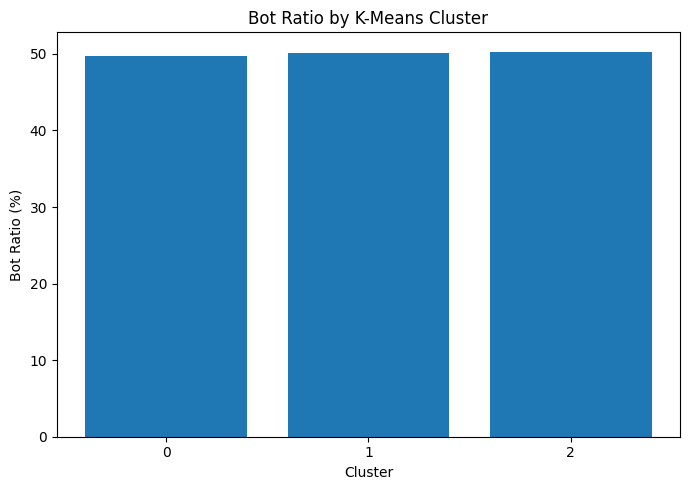

In [25]:
plt.figure(figsize=(7, 5))
plt.bar(cluster_summary["cluster"].astype(str), cluster_summary["bot_ratio"])
plt.title("Bot Ratio by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Bot Ratio (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bot_ratio_by_cluster.png", dpi=300)
plt.show()

## 13. Trực quan hóa phân bố Anomaly Score

Biểu đồ histogram cho thấy phân bố điểm bất thường của người dùng.

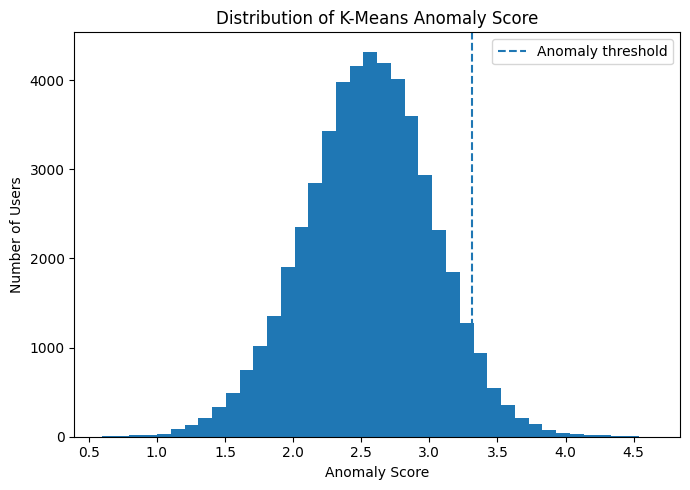

In [26]:
plt.figure(figsize=(7, 5))
plt.hist(df_kmeans_result["anomaly_score"], bins=40)
plt.axvline(threshold, linestyle="--", label="Anomaly threshold")
plt.title("Distribution of K-Means Anomaly Score")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_anomaly_score_distribution.png", dpi=300)
plt.show()

**Nhận xét:**

Đường ngưỡng trên biểu đồ biểu diễn ranh giới top 5% anomaly score. Các điểm nằm bên phải đường này được xem là nhóm có hành vi bất thường theo K-Means.

## 14. Giảm chiều dữ liệu bằng PCA để trực quan hóa

Dữ liệu ban đầu có nhiều feature nên khó vẽ trực tiếp. Ta dùng **PCA** để giảm dữ liệu về 2 chiều nhằm trực quan hóa các cụm.

Lưu ý:

- PCA ở đây chỉ dùng để vẽ biểu đồ.
- K-Means vẫn được huấn luyện trên dữ liệu đã chuẩn hóa đầy đủ, không phải chỉ trên 2 chiều PCA.

In [27]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame({
    "pca_1": pca_components[:, 0],
    "pca_2": pca_components[:, 1],
    "cluster": df_kmeans_result["cluster"],
    "bot_label": df_kmeans_result["bot_label"],
    "is_anomaly": df_kmeans_result["is_anomaly"]
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

df_pca.head()

Explained variance ratio: [0.18386128 0.11307209]
Total explained variance: 0.2969333644811424


,pca_1,pca_2,cluster,bot_label,is_anomaly
0,-2.668869,-0.884062,1,1,0
1,0.136385,0.333582,0,0,0
2,0.135368,-0.292727,0,0,0
3,0.926824,0.783074,0,1,0
4,0.123422,2.764007,2,1,0


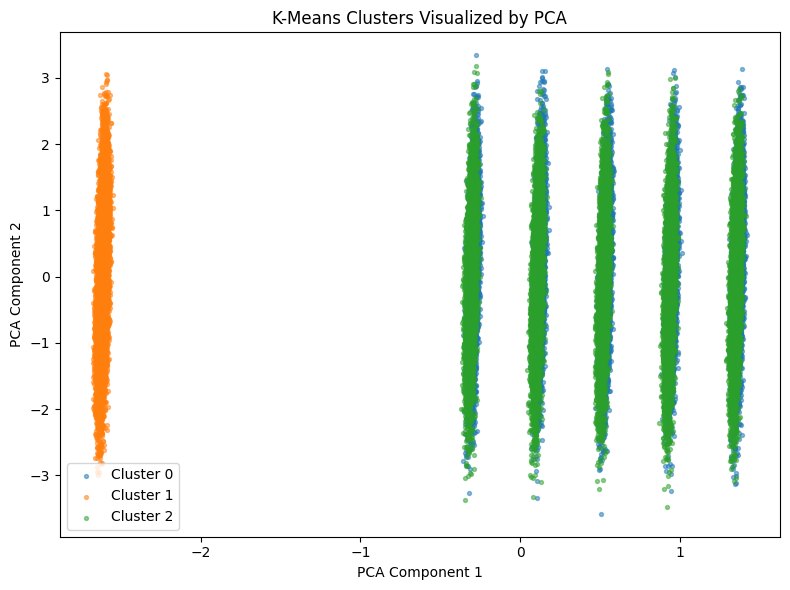

In [28]:
plt.figure(figsize=(8, 6))

for cluster in sorted(df_pca["cluster"].unique()):
    subset = df_pca[df_pca["cluster"] == cluster]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        s=8,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.title("K-Means Clusters Visualized by PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_kmeans.png", dpi=300)
plt.show()

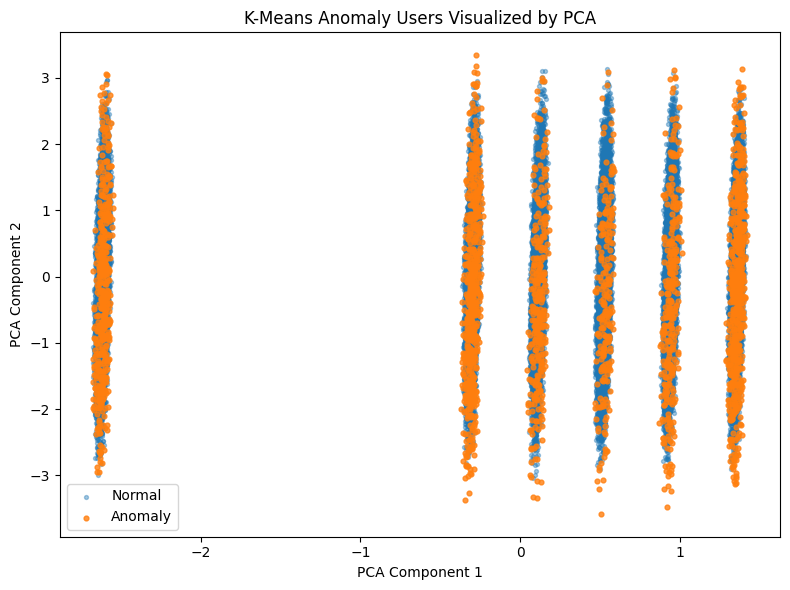

In [29]:
plt.figure(figsize=(8, 6))

normal_points = df_pca[df_pca["is_anomaly"] == 0]
anomaly_points = df_pca[df_pca["is_anomaly"] == 1]

plt.scatter(
    normal_points["pca_1"],
    normal_points["pca_2"],
    s=8,
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    anomaly_points["pca_1"],
    anomaly_points["pca_2"],
    s=12,
    alpha=0.8,
    label="Anomaly"
)

plt.title("K-Means Anomaly Users Visualized by PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_kmeans_anomaly.png", dpi=300)
plt.show()

**Nhận xét:**

Biểu đồ PCA giúp quan sát tương đối sự phân bố của các cụm và nhóm bất thường. Nếu các điểm anomaly nằm nhiều ở rìa phân bố, điều đó phù hợp với cách tính anomaly score dựa trên khoảng cách đến tâm cụm.

Tuy nhiên, PCA chỉ giữ lại một phần phương sai của dữ liệu nên biểu đồ chỉ mang tính trực quan, không phải bằng chứng đánh giá duy nhất.

## 15. Lưu kết quả K-Means và mô hình

Lưu các file sau:

```text
results/csv/kmeans_clustered_users.csv
results/csv/kmeans_anomaly_users.csv
results/models/kmeans_model.pkl
results/models/pca_model.pkl
```

In [31]:
from pathlib import Path
import joblib

RESULT_CSV_DIR = Path("../results/csv")
MODEL_DIR = Path("../results/models")

RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

KMEANS_RESULT_PATH = RESULT_CSV_DIR / "kmeans_clustered_users.csv"
KMEANS_ANOMALY_PATH = RESULT_CSV_DIR / "kmeans_anomaly_users.csv"
KMEANS_MODEL_PATH = MODEL_DIR / "kmeans_model.pkl"
PCA_MODEL_PATH = MODEL_DIR / "pca_model.pkl"

In [32]:
df_kmeans_result.to_csv(KMEANS_RESULT_PATH, index=False)

df_kmeans_result[df_kmeans_result["is_anomaly"] == 1].to_csv(
    KMEANS_ANOMALY_PATH,
    index=False
)

joblib.dump(kmeans, KMEANS_MODEL_PATH)
joblib.dump(pca, PCA_MODEL_PATH)

print("Saved K-Means result to:", KMEANS_RESULT_PATH)
print("Saved K-Means anomaly users to:", KMEANS_ANOMALY_PATH)
print("Saved K-Means model to:", KMEANS_MODEL_PATH)
print("Saved PCA model to:", PCA_MODEL_PATH)

Saved K-Means result to: ../results/csv/kmeans_clustered_users.csv
Saved K-Means anomaly users to: ../results/csv/kmeans_anomaly_users.csv
Saved K-Means model to: ../results/models/kmeans_model.pkl
Saved PCA model to: ../results/models/pca_model.pkl


## 16. Kết luận K-Means Clustering

Sau khi thực hiện K-Means Clustering, có thể rút ra các ý chính:

1. Dữ liệu đã chuẩn hóa được sử dụng để chạy K-Means.
2. Elbow Method và Silhouette Score được dùng để khảo sát số cụm phù hợp.
3. Nếu Silhouette Score cao nhất tại `k = 2`, dữ liệu có xu hướng tách tốt nhất thành 2 cụm theo tiêu chí định lượng.
4. Trong trường hợp chọn `k = 3`, lý do là để phục vụ mục tiêu phân tích nhiều nhóm hành vi người dùng hơn.
5. Sau khi chạy K-Means, mỗi người dùng được gán vào một cụm hành vi.
6. `anomaly_score` được tính bằng khoảng cách từ người dùng đến tâm cụm gần nhất.
7. Nhóm top 5% `anomaly_score` cao nhất được xem là nhóm người dùng có hành vi bất thường.
8. Bảng `cluster_summary` giúp diễn giải từng cụm theo các đặc trưng hành vi.
9. Bảng `anomaly_summary` giúp kiểm tra nhóm bất thường có tỷ lệ bot cao hơn nhóm còn lại hay không.
10. PCA được sử dụng để trực quan hóa cụm và nhóm bất thường trên mặt phẳng 2 chiều.